# The MBRA global nonlocal dispersive optical potential

This notebook demonstrates `jitr.optical_potentials.mbra` — the global
*nonlocal and dispersive* neutron optical model of
[B. Morillon, G. Blanchon, P. Romain and H. F. Arellano,
arXiv:2403.05843 (2024)](https://arxiv.org/abs/2403.05843)
(called "NLD" in the paper), valid for $16 \le A \le 209$ and incident
energies from 1 keV to 250 MeV.

The model is a dispersive extension of the Perey–Buck potential: the real
volume, real+imaginary surface, and real+imaginary spin-orbit terms all share
a Gaussian nonlocality form factor of range $\beta = 0.915$ fm, while the
imaginary volume term is local. The energy dependence of the real terms is
generated entirely by dispersion relations acting on the imaginary depths.

We reproduce, for $n + {}^{208}$Pb (and $^{40}$Ca, $^{89}$Y where shown in
the paper):

1. **the nonlocal partial-wave kernels** $\nu_l(r, r')$ (paper Eq. 7),
2. **the depths and dispersive corrections vs energy** (paper Fig. 3),
3. **differential elastic cross sections** (paper Fig. 6), and
4. **the total cross section from 0.3 to 250 MeV** (paper Fig. 5),

with EXFOR data overlaid in (3) and (4). Along the way this exercises two
headline capabilities of the `jitr.xs` workspaces: $\ell$-dependent
nonlocal kernels (`l_dependent=True`) and energy-grid vectorization.

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.lines import Line2D

import jitr
from jitr.optical_potentials import mbra

In [2]:
neutron = (1, 0)
target = (208, 82)
reaction = jitr.reactions.Reaction(target=target, projectile=neutron, process="EL")
# the paper's E_F = -[S_n(Z, N) + S_n(Z, N+1)]/2, from jitr's mass tables
print(f"E_F(208Pb) = {reaction.Ef:.3f} MeV")

E_F(208Pb) = -5.653 MeV


In [3]:
def mbra_terms(workspace, reaction, kinematics):
    """Assemble the three MBRA terms on a workspace's grid, stacked over
    the energy grid: l-dependent nonlocal central, local central, and
    l-dependent nonlocal spin-orbit. One vectorized call evaluates all
    depths per energy grid and builds the Perey-Buck kernel once, shared
    between the two nonlocal terms."""
    return mbra.assemble_terms(
        workspace.radial_grid(),
        np.arange(workspace.lmax + 1),
        (reaction.projectile.A, reaction.projectile.Z),
        (reaction.target.A, reaction.target.Z),
        kinematics.Elab,
        reaction.Ef,
    )


def mbra_interaction(workspace, reaction, kinematics):
    """Compose the full MBRA interaction for a workspace."""
    K_nl, W_loc, K_so = mbra_terms(workspace, reaction, kinematics)
    return (
        workspace.central(K_nl, l_dependent=True, energy_dependent=True)
        + workspace.central(W_loc, energy_dependent=True)
        + workspace.spin_orbit(K_so, l_dependent=True, energy_dependent=True)
    )

## 1. The nonlocal kernels

In partial waves the Perey–Buck form $V(\mathbf{r}, \mathbf{r}') =
U\!\left(\tfrac{r+r'}{2}\right) H(|\mathbf{r}-\mathbf{r}'|)$ becomes
(paper Eq. 7)

$$\nu_l(r, r') = \frac{4 r r'}{\sqrt{\pi}\beta^3}\,
  U\!\left(\frac{r+r'}{2}\right)
  e^{-(r^2+r'^2)/\beta^2}\, i_l\!\left(\frac{2 r r'}{\beta^2}\right),$$

an intrinsically $\ell$-dependent nonlocal kernel: the modified spherical
Bessel factor suppresses the kernel near the origin more strongly for higher
$\ell$. The kernel is concentrated within $\sim\beta$ of the diagonal.

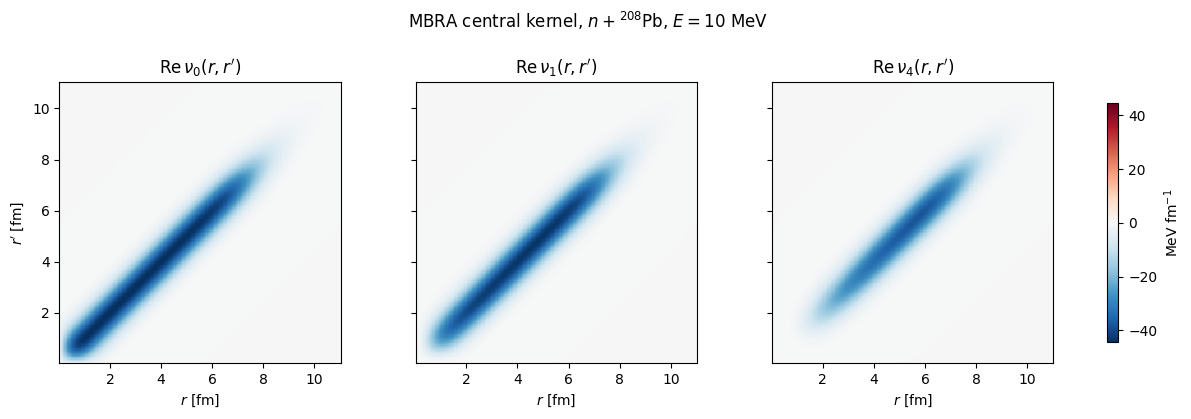

In [4]:
r_plot = np.linspace(0.05, 11.0, 220)
Elab_demo = 10.0
nl_p, loc_p, so_p = mbra.calculate_params(neutron, target, Elab_demo, reaction.Ef)
K_demo = mbra.central_nonlocal(r_plot, np.array([0, 1, 4]), *nl_p)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), sharey=True, constrained_layout=True)
vmax = np.max(np.abs(K_demo.real))
for ax, K, l in zip(axes, K_demo, (0, 1, 4), strict=True):
    im = ax.pcolormesh(r_plot, r_plot, K.real, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    ax.set_title(rf"$\mathrm{{Re}}\,\nu_{{{l}}}(r, r')$")
    ax.set_xlabel(r"$r$ [fm]")
    ax.set_aspect("equal")
axes[0].set_ylabel(r"$r'$ [fm]")
fig.colorbar(im, ax=axes, label=r"MeV fm$^{-1}$", shrink=0.85)
fig.suptitle(
    rf"MBRA central kernel, $n + {{}}^{{208}}$Pb, $E = {Elab_demo:.0f}$ MeV", y=1.12
);

## 2. Depths and dispersive corrections vs energy (paper Fig. 3)

The imaginary depths $W^{NL}_S$, $W^L_V$, $W^{NL}_{so}$ (Eqs. 13–17 and
Table I) and their dispersive corrections $\Delta V$, for the three nuclei
shown in the paper. Compare directly with Fig. 3 of arXiv:2403.05843.

Three implementation notes (see the `mbra` module docstring):

- Table I prints the sub-Fermi volume depth as "$-8.400A$" — a typo: the
  authors have confirmed (private communication, 2026) it is a constant
  $A_V^- = -8.400$ MeV with no mass dependence, which `jitr` uses. Note the
  paper's own Fig. 3(b) is inconsistent with this value: its $\approx -3$ MeV
  sub-Fermi $W^L_V$ dip corresponds to a depth near $-48.4$ MeV, while
  $-8.400$ MeV gives a $-0.53$ MeV dip (and $\Delta V^L_V(80) \approx -6.5$
  vs the figure's $\approx -8.6$ MeV). Section 2b below investigates.
- $\Delta V^{NL}_{so}$ follows the closed form of VanderKam *et al.*
  (the paper's Ref. [28]), symmetric about $E_F$ — the only convention that
  reproduces the even curve of Fig. 3(c).
- $\Delta V^{NL}_S$ and $\Delta V^L_V$ are evaluated in *closed form* by
  default: exact half-line pole/residue expressions (after Quesada,
  Capote, Molina, Lozano & Raynal, PRC **67**, 067601 (2003)) composed for
  the asymmetric MBRA depths, plus the ECIS-06 partner of the
  Mahaux–Sartor $\sqrt{E}$ tail. `method="numerical"` retains the PV
  quadrature, which agrees to $\lesssim 0.1$ MeV.

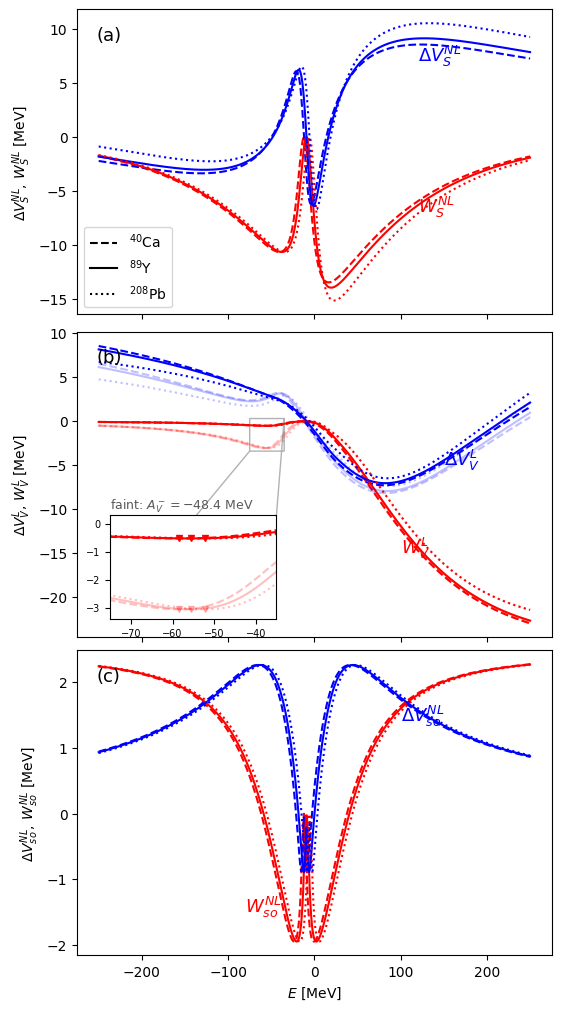

In [5]:
cases = [((40, 20), "dashed"), ((89, 39), "solid"), ((208, 82), "dotted")]
E_grid = np.linspace(-250.0, 250.0, 600)

fig, (ax1, ax2, ax3) = plt.subplots(
    3, 1, figsize=(5.5, 10), sharex=True, constrained_layout=True
)
# inset: zoom on the sub-Fermi W_V^L minima (at E_F - 46.5 per nucleus), where
# the horizontal offsets between the nuclei are purely the E_F differences;
# markers sit on each curve's minimum
axins = ax2.inset_axes([0.07, 0.06, 0.35, 0.34])
for (A, Z), style in cases:
    rxn = jitr.reactions.Reaction(target=(A, Z), projectile=neutron, process="EL")
    Ef = rxn.Ef
    c = mbra.resolve_coefficients(A)
    s_args = (c.AS_plus, c.AS_minus, c.BS, c.CS)
    v_args = (c.AV_plus, c.AV_minus, c.BV, c.EV_plus, c.EV_minus, c.ALPHA)
    so_args = (c.ASO, c.BSO, c.CSO, c.DSO)
    ax1.plot(E_grid, mbra.Ws_depth(E_grid, Ef, *s_args), color="r", ls=style)
    ax1.plot(E_grid, mbra.delta_Vs_depth(E_grid, Ef, *s_args), color="b", ls=style)
    ax2.plot(E_grid, mbra.Wv_depth(E_grid, Ef, *v_args), color="r", ls=style)
    ax2.plot(E_grid, mbra.delta_Vv_depth(E_grid, Ef, *v_args), color="b", ls=style)
    # faint: the sub-Fermi depth the paper's Fig. 3(b) corresponds to
    # (A_V^- = -48.4 MeV, see sections 2b/2c) instead of the confirmed -8.4
    v48 = (c.AV_plus, -48.4, c.BV, c.EV_plus, c.EV_minus, c.ALPHA)
    ax2.plot(E_grid, mbra.Wv_depth(E_grid, Ef, *v48), color="r", ls=style, alpha=0.25)
    ax2.plot(
        E_grid, mbra.delta_Vv_depth(E_grid, Ef, *v48), color="b", ls=style, alpha=0.25
    )
    E_fine = Ef + np.linspace(-60.0, -30.0, 2001)
    for args, al in ((v_args, 1.0), (v48, 0.25)):
        Wf = mbra.Wv_depth(E_fine, Ef, *args)
        axins.plot(E_grid, mbra.Wv_depth(E_grid, Ef, *args), color="r", ls=style,
                   alpha=al)
        i = np.argmin(Wf)
        axins.plot(E_fine[i], Wf[i], marker="v", color="r", ms=4, alpha=al, zorder=5)
    ax3.plot(E_grid, mbra.Wso_depth(E_grid, Ef, *so_args), color="r", ls=style)
    ax3.plot(E_grid, mbra.delta_Vso_depth(E_grid, Ef, *so_args), color="b", ls=style)

axins.set_xlim(-75.0, -35.0)
axins.set_ylim(-3.4, 0.3)
axins.tick_params(labelsize=7)
ax2.indicate_inset_zoom(axins, edgecolor="0.4")

ax1.set_ylabel(r"$\Delta V_S^{NL},\, W_S^{NL}$ [MeV]")
ax1.annotate(r"$\Delta V_S^{NL}$", (120, 7), color="b", fontsize=13)
ax1.annotate(r"$W_S^{NL}$", (120, -7), color="r", fontsize=13)
ax2.set_ylabel(r"$\Delta V_V^{L},\, W_V^{L}$ [MeV]")
ax2.annotate(r"$\Delta V_V^{L}$", (150, -5), color="b", fontsize=13)
ax2.annotate(r"$W_V^{L}$", (100, -15), color="r", fontsize=13)
ax2.text(
    0.07, 0.42, r"faint: $A_V^- = -48.4$ MeV", transform=ax2.transAxes,
    color="0.35", fontsize=9,
)
ax3.set_ylabel(r"$\Delta V_{so}^{NL},\, W_{so}^{NL}$ [MeV]")
ax3.annotate(r"$\Delta V_{so}^{NL}$", (100, 1.4), color="b", fontsize=13)
ax3.annotate(r"$W_{so}^{NL}$", (-80, -1.5), color="r", fontsize=13)
ax3.set_xlabel(r"$E$ [MeV]")
for ax, panel in zip((ax1, ax2, ax3), "abc", strict=True):
    ax.text(0.04, 0.9, f"({panel})", transform=ax.transAxes, fontsize=13)
names = (r"$^{40}$Ca", r"$^{89}$Y", r"$^{208}$Pb")
ax1.legend(
    handles=[
        Line2D([], [], color="k", ls=style, label=name)
        for ((A, Z), style), name in zip(cases, names, strict=True)
    ],
    loc="lower left",
);

### 2a. How much of the A-dependence in Fig. 3 is just the Fermi-energy offset?

Both the plot above and the paper's Fig. 3 use the *absolute* energy $E$ on
the x-axis, so the per-nucleus Fermi energies ($E_F \approx -12.0$, $-9.2$,
$-5.7$ MeV for $^{40}$Ca, $^{89}$Y, $^{208}$Pb) shift every curve by a
different amount. Replotting against $x = E - E_F$ isolates the genuine mass
dependence: of the depth parameters, only $A_S^+$, $A_V^+$, $E_V^+$ and
$\alpha$ depend on $A$ — every sub-Fermi parameter ($A_S^-$, $A_V^-$, $B$'s,
$C_S$, $E_V^-$, all spin-orbit parameters) is constant.

The printed max-spread table confirms what this implies:

- panel (c) collapses to *zero* spread in $x$ — the spin-orbit
  A-dependence visible in Fig. 3 is purely the $E_F$ offset;
- the sub-Fermi $W$ curves of panels (a) and (b) collapse exactly in $x$
  (machine-precision spread), so any sub-Fermi splitting of the red curves
  in Fig. 3(b) is likewise pure $E_F$ offset — the $-8.4$ vs $-48.4$ MeV
  depth question of section 2b cannot be an A-dependence effect;
- the surface panel's spread drops from $\sim 6$–$8$ MeV vs $E$ to
  $\sim 2$ MeV vs $x$ (the genuine $A_S^+$ mass dependence), while the
  volume panel's $\sim 1.5$–$2$ MeV spread is mostly genuine
  ($A_V^+$, $E_V^+$, $\alpha$) and barely changes.

max spread across the three nuclei [MeV] (W / dV):
  (a)  vs E:  6.18 /  7.83   vs E-E_F:  1.68 /  1.99   vs E-E_F, W below E_F only: 0.00e+00
  (b)  vs E:  1.60 /  1.79   vs E-E_F:  1.29 /  1.96   vs E-E_F, W below E_F only: 0.00e+00
  (c)  vs E:  1.72 /  1.01   vs E-E_F:  0.00 /  0.00   vs E-E_F, W below E_F only: 0.00e+00


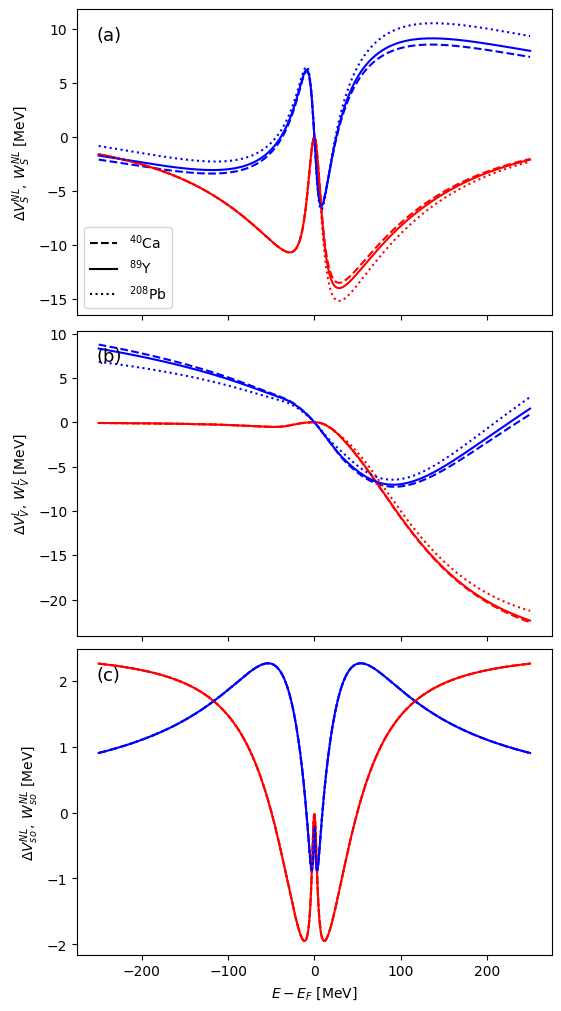

In [6]:
x_grid = np.linspace(-250.0, 250.0, 600)


def panel_curves(A, E_eval, Ef):
    c = mbra.resolve_coefficients(A)
    s_args = (c.AS_plus, c.AS_minus, c.BS, c.CS)
    v_args = (c.AV_plus, c.AV_minus, c.BV, c.EV_plus, c.EV_minus, c.ALPHA)
    so_args = (c.ASO, c.BSO, c.CSO, c.DSO)
    return [
        (mbra.Ws_depth(E_eval, Ef, *s_args), mbra.delta_Vs_depth(E_eval, Ef, *s_args)),
        (mbra.Wv_depth(E_eval, Ef, *v_args), mbra.delta_Vv_depth(E_eval, Ef, *v_args)),
        (
            mbra.Wso_depth(E_eval, Ef, *so_args),
            mbra.delta_Vso_depth(E_eval, Ef, *so_args),
        ),
    ]


fermi = {
    A: jitr.reactions.Reaction(target=(A, Z), projectile=neutron, process="EL").Ef
    for (A, Z), _ in cases
}
vs_E = {A: panel_curves(A, E_grid, fermi[A]) for (A, _), _ in cases}
vs_x = {A: panel_curves(A, fermi[A] + x_grid, fermi[A]) for (A, _), _ in cases}

fig, axes = plt.subplots(3, 1, figsize=(5.5, 10), sharex=True, constrained_layout=True)
for (A, Z), style in cases:
    for ax, (W, dV) in zip(axes, vs_x[A], strict=True):
        ax.plot(x_grid, W, color="r", ls=style)
        ax.plot(x_grid, dV, color="b", ls=style)
ylabels = (
    r"$\Delta V_S^{NL},\, W_S^{NL}$ [MeV]",
    r"$\Delta V_V^{L},\, W_V^{L}$ [MeV]",
    r"$\Delta V_{so}^{NL},\, W_{so}^{NL}$ [MeV]",
)
for ax, ylab, panel in zip(axes, ylabels, "abc", strict=True):
    ax.set_ylabel(ylab)
    ax.text(0.04, 0.9, f"({panel})", transform=ax.transAxes, fontsize=13)
axes[-1].set_xlabel(r"$E - E_F$ [MeV]")
axes[0].legend(
    handles=[
        Line2D([], [], color="k", ls=style, label=name)
        for ((A, Z), style), name in zip(cases, names, strict=True)
    ],
    loc="lower left",
)

As = [A for (A, _), _ in cases]
sub = x_grid < 0.0
print("max spread across the three nuclei [MeV] (W / dV):")
for i, panel in enumerate("abc"):
    sE_W, sE_D = (
        np.max(np.ptp(np.stack([vs_E[A][i][j] for A in As]), axis=0)) for j in (0, 1)
    )
    sx_W, sx_D = (
        np.max(np.ptp(np.stack([vs_x[A][i][j] for A in As]), axis=0)) for j in (0, 1)
    )
    sub_W = np.max(np.ptp(np.stack([vs_x[A][i][0] for A in As]), axis=0)[sub])
    print(
        f"  ({panel})  vs E: {sE_W:5.2f} / {sE_D:5.2f}"
        f"   vs E-E_F: {sx_W:5.2f} / {sx_D:5.2f}"
        f"   vs E-E_F, W below E_F only: {sub_W:.2e}"
    )

### 2b. Which dispersion convention is Fig. 3(b)?

The closed forms published by Quesada *et al.* (PRC **67**, 067601) assume
the symmetry condition $W(2E_F - E) = W(E)$ (their Eq. 7), which the
asymmetric MBRA depths violate. Since the paper says dispersive terms are
"obtained analytically" when possible — and its $\Delta V_{so}$ already uses
a symmetric convention — one hypothesis is that Fig. 3(b) was produced with
a symmetric-convention $\Delta V_V$ rather than the causal dispersion of the
actual asymmetric $W_V$. We compare, for $^{208}$Pb:

1. the exact asymmetric dispersion of Eqs. 14–16 with the author-confirmed
   $A_V^- = -8.4$ MeV (what `jitr` uses),
2. the symmetric Quesada form with $A_V^+$ on both sides,
3. the symmetric Quesada form with $A_V^-$ on both sides,
4. the exact asymmetric dispersion with $A_V^- = -48.4$ MeV — the depth the
   figure's $\approx -3$ MeV sub-Fermi dip corresponds to.

**Conclusion (from the printed anchor table):** the symmetric convention
does *not* explain the figure — with $A_V^+$ it more than doubles the
correction ($\Delta V_V(80) \approx -13$ vs the figure's $-8.6$) and gives a
$-5.1$ MeV sub-Fermi dip; with $A_V^-$ it nearly kills both. The figure's
$W_V^L$ dip *depth* is matched only by $A_V^- \approx -48.4$ MeV, but even
then its $\Delta V_V$ disagrees ($-7.3$ vs $-8.6$ at $+80$ MeV, $-0.8$ vs
$+0.5$ at $E=0$): no causal dispersion of any of these $W$'s reproduces
panel (b), suggesting the figure's $\Delta V_V$ also treats the $\sqrt{E}$
tail differently. (Section 2c digitizes the figure and shows its sub-Fermi
dip *positions* are additionally displaced by $\approx 2E_F$ per nucleus.)
These variants are shown for diagnosis only; the library implements the
causal dispersion of the published Eqs. 14–16 with the author-confirmed
$-8.4$ MeV.

anchors:   figure reads  W(-60) ~ -3.0,  dV(0) ~ +0.5,  dV(80) ~ -8.6
  exact asymmetric, A_V^- = -8.4 (jitr)            W(-60)= -0.51  dV(0)= -0.63  dV(80)= -6.46
  symmetric (Quesada Eq. 7), A_V^+ both sides      W(-60)= -5.10  dV(0)= -1.29  dV(80)=-13.03
  symmetric (Quesada Eq. 7), A_V^- both sides      W(-60)= -1.17  dV(0)= -0.12  dV(80)= -0.29
  exact asymmetric, A_V^- = -48.4                  W(-60)= -2.96  dV(0)= -0.80  dV(80)= -7.33


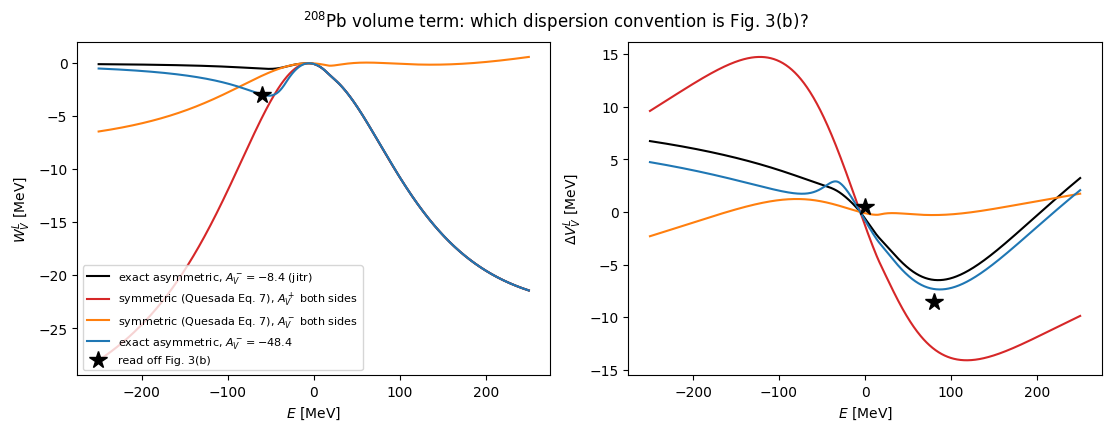

In [7]:
from jitr.optical_potentials import dispersion

Ef = reaction.Ef
c = mbra.resolve_coefficients(208)
v_args = (c.AV_plus, c.AV_minus, c.BV, c.EV_plus, c.EV_minus, c.ALPHA)
E_v = np.linspace(-250.0, 250.0, 1001)
x_v = E_v - Ef
tail_partner = c.ALPHA * dispersion.sqrt_tail_dispersive_partner(Ef + c.EV_plus, E_v, Ef)


def Wv_symmetric(A_both):
    """Eqs. 14-15 with one amplitude both sides and no Eq. 16 suppression
    (the pure Quesada Eq. 5/7 shape, plus the sqrt(E) tail)."""
    W = A_both * x_v**2 / (x_v**2 + c.BV**2)
    y = Ef + c.EV_plus
    hi = E_v > y
    W[hi] += c.ALPHA * (np.sqrt(E_v[hi]) + y**1.5 / (2 * E_v[hi]) - 1.5 * np.sqrt(y))
    return W


v48 = (c.AV_plus, -48.4, c.BV, c.EV_plus, c.EV_minus, c.ALPHA)
variants = {
    r"exact asymmetric, $A_V^- = -8.4$ (jitr)": (
        mbra.Wv_depth(E_v, Ef, *v_args),
        mbra.delta_Vv_depth(E_v, Ef, *v_args),
    ),
    r"symmetric (Quesada Eq. 7), $A_V^+$ both sides": (
        Wv_symmetric(c.AV_plus),
        c.AV_plus * c.BV * x_v / (x_v**2 + c.BV**2) + tail_partner,
    ),
    r"symmetric (Quesada Eq. 7), $A_V^-$ both sides": (
        Wv_symmetric(c.AV_minus),
        c.AV_minus * c.BV * x_v / (x_v**2 + c.BV**2) + tail_partner,
    ),
    r"exact asymmetric, $A_V^- = -48.4$": (
        mbra.Wv_depth(E_v, Ef, *v48),
        mbra.delta_Vv_depth(E_v, Ef, *v48),
    ),
}

fig, (axW, axD) = plt.subplots(
    1, 2, figsize=(11, 4.2), sharex=True, constrained_layout=True
)
colors = ("k", "tab:red", "tab:orange", "tab:blue")
for (label, (W, dV)), color in zip(variants.items(), colors, strict=True):
    axW.plot(E_v, W, color=color, label=label)
    axD.plot(E_v, dV, color=color)
axW.plot([-60.0], [-3.0], "k*", ms=13, label="read off Fig. 3(b)")
axD.plot([80.0, 0.0], [-8.6, 0.5], "k*", ms=13)
axW.set_ylabel(r"$W_V^{L}$ [MeV]")
axD.set_ylabel(r"$\Delta V_V^{L}$ [MeV]")
for ax in (axW, axD):
    ax.set_xlabel(r"$E$ [MeV]")
axW.legend(fontsize=8, loc="lower left")
fig.suptitle(r"$^{208}$Pb volume term: which dispersion convention is Fig. 3(b)?")

print("anchors:   figure reads  W(-60) ~ -3.0,  dV(0) ~ +0.5,  dV(80) ~ -8.6")
for label, (W, dV) in variants.items():
    iW = np.argmin(np.abs(E_v + 60.0))
    i0 = np.argmin(np.abs(E_v))
    i80 = np.argmin(np.abs(E_v - 80.0))
    print(
        f"  {label.replace('$', ''):48s}"
        f" W(-60)={W[iW]:6.2f}  dV(0)={dV[i0]:6.2f}  dV(80)={dV[i80]:6.2f}"
    )

### 2c. The Fig. 3(b) mass dependence: Fermi offsets, a lab/c.m. frame effect, or neither?

The figure's sub-Fermi $W_V^L$ minima are shifted between the three nuclei by
more than section 2a's pure-$E_F$-offset prediction. Two candidate
explanations were tested against a *digitization of the published figure*
(the PDF is vector art; curves extracted from its paths, axes calibrated on
the tick marks to $\sim 0.25$ MeV):

1. **Frame mix-up** (the model's energy argument being $E_{cm}$ while the
   axis is $E_{lab}$, or vice versa) — stretches every curve by
   $(A+1)/A$ or $A/(A+1)$, at most $\sim 1.5$ MeV at these features and
   *largest for the lightest nucleus*.
2. **Pure $E_F$ offsets** (jitr's convention, $E$ as-is).

**Both are ruled out by the measurement.** The frame-insensitive $E_F$
markers (the cusps of $W_S$ in panel (a) and $W_{so}$ in panel (c)) sit at
AME2020 Fermi energies to $\lesssim 0.5$ MeV — confirming the figure's axis,
the formulas' energy argument, and jitr's $E_F$ values are all mutually
consistent — and the $W_S$ minima triples likewise match jitr's curves to
$0.3$–$0.7$ MeV. But the sub-Fermi $W_V^L$ minima sit at
$E = -82.2 / -74.9 / -64.1$ MeV: displaced from the Eqs. 14–16 prediction by
$-23.7 / -19.3 / -12.0$ MeV — an order of magnitude beyond any frame effect,
and following $\approx 2E_F$ per nucleus.

Empirically the figure's sub-Fermi branch is reproduced (rms
$0.3$–$0.6$ MeV, see the overlay below) by Eqs. 14–16 with
$A_V^- \approx -48.4$ MeV **and the branch evaluated at $E - 2E_F$**
(equivalently $x = E - 3E_F$; dips at $3E_F - 46.5$, depth $\approx -2.8$
MeV for all three nuclei). So the extra "mass dependence" in the figure is
the $2E_F$ displacement of an (evidently buggy or differently-conventioned)
sub-Fermi branch in the code that produced it — not a frame conversion, and
not reproducible by any parameter reading of the published formulas.
A further check: dispersing the figure's *own* digitized $W_V$ causally
still misses the figure's $\Delta V_V$ by $2$–$5$ MeV at $|E| = 250$ MeV
(wrong sign of the high-$E$ tail), reaffirming that its $\Delta V_V$ also
treats the $\sqrt{E}$-tail dispersion differently. `jitr` keeps the
published Eqs. 14–16 with the author-confirmed $A_V^- = -8.4$ MeV; the
$2E_F$ shift and the tail prescription join the author-questions list.

E_F markers in the figure (cusp positions) vs AME2020 [MeV]:
  A= 40:  panel (a)  -11.73   panel (c)  -11.78   AME2020  -12.00
  A= 89:  panel (a)   -9.09   panel (c)   -9.18   AME2020   -9.17
  A=208:  panel (a)   -5.48   panel (c)   -5.55   AME2020   -5.65

sub-Fermi W_V^L minimum: measured vs hypotheses [MeV]:
    A  measured  H0: Ef+x H1: (A+1)/A H2: A/(A+1)    3Ef+x
   40    -82.15    -58.50      -59.96      -57.07   -82.50
   89    -74.94    -55.67      -56.30      -55.05   -74.01
  208    -64.07    -52.15      -52.40      -51.90   -63.46


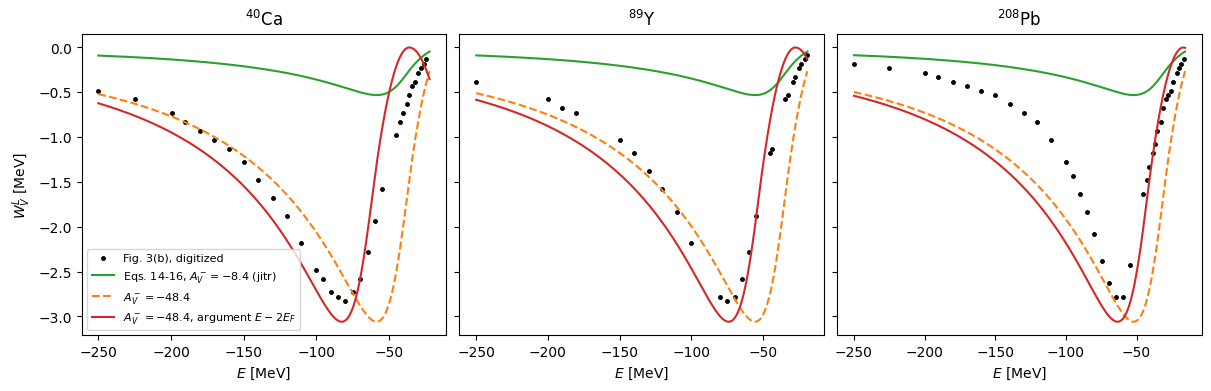

In [8]:
# Digitized from Fig. 3 of PhysRevC.109.044611: the figure is vector art, so
# the curves were extracted from the PDF's SVG paths and calibrated against
# the axis ticks (E-axis rms 0.24 MeV, W-axis rms ~0.01 MeV; the figure's own
# coordinate grid quantizes at ~0.8 MeV).
FIG3_EF_CUSPS = {  # measured E_F markers: (W_S cusp panel (a), W_so cusp (c))
    40: (-11.73, -11.78),
    89: (-9.09, -9.18),
    208: (-5.48, -5.55),
}
FIG3B_WV_DIPS = {  # measured (E_dip, depth) of the sub-Fermi W_V^L minima
    40: (-82.15, -2.81),
    89: (-74.94, -2.83),
    208: (-64.07, -2.79),
}
FIG3B_WV_SUBFERMI = {  # digitized panel-(b) red curves below E_F (E, W) [MeV]
    40: [(-250.2, -0.48), (-224.9, -0.58), (-199.6, -0.73), (-190.4, -0.83),
         (-180.2, -0.93), (-170.1, -1.03), (-160.0, -1.13), (-149.9, -1.28),
         (-139.8, -1.48), (-129.7, -1.68), (-120.4, -1.88), (-110.3, -2.18),
         (-100.1, -2.48), (-95.1, -2.58), (-90.0, -2.73), (-85.0, -2.78),
         (-79.9, -2.83), (-74.8, -2.73), (-69.8, -2.58), (-64.7, -2.28),
         (-59.7, -1.93), (-54.6, -1.58), (-45.3, -0.98), (-42.0, -0.83),
         (-40.3, -0.73), (-37.7, -0.63), (-36.1, -0.53), (-34.4, -0.43),
         (-31.8, -0.38), (-30.1, -0.28), (-27.6, -0.23), (-25.9, -0.18),
         (-24.2, -0.13)],
    89: [(-250.2, -0.38), (-199.6, -0.58), (-190.4, -0.68), (-180.2, -0.73),
         (-149.9, -1.03), (-139.8, -1.18), (-129.7, -1.38), (-120.4, -1.58),
         (-110.3, -1.83), (-100.1, -2.18), (-79.9, -2.78), (-74.8, -2.83),
         (-69.8, -2.78), (-64.7, -2.58), (-59.7, -2.28), (-54.6, -1.88),
         (-45.3, -1.18), (-43.6, -1.13), (-34.4, -0.58), (-32.7, -0.53),
         (-29.3, -0.38), (-27.6, -0.33), (-25.1, -0.23), (-23.4, -0.18),
         (-20.9, -0.13), (-19.2, -0.08)],
    208: [(-250.2, -0.18), (-224.9, -0.23), (-199.6, -0.28), (-190.4, -0.33),
          (-180.2, -0.38), (-170.1, -0.43), (-160.0, -0.48), (-149.9, -0.53),
          (-139.8, -0.63), (-129.7, -0.73), (-120.4, -0.83), (-110.3, -1.03),
          (-100.1, -1.28), (-95.1, -1.43), (-90.0, -1.63), (-85.0, -1.83),
          (-79.9, -2.08), (-74.8, -2.38), (-69.8, -2.63), (-64.7, -2.78),
          (-59.7, -2.78), (-54.6, -2.43), (-45.3, -1.63), (-42.8, -1.48),
          (-41.1, -1.33), (-38.6, -1.18), (-36.9, -1.08), (-35.2, -0.93),
          (-32.7, -0.83), (-31.0, -0.68), (-29.3, -0.58), (-27.6, -0.53),
          (-25.9, -0.48), (-24.2, -0.38), (-21.7, -0.28), (-20.0, -0.23),
          (-18.3, -0.18), (-16.7, -0.13)],
}
X_DIP_MODEL = -46.5  # A-independent minimum offset x = E - E_F of Eqs. 14-16

print("E_F markers in the figure (cusp positions) vs AME2020 [MeV]:")
for A in (40, 89, 208):
    ca_, cc_ = FIG3_EF_CUSPS[A]
    print(f"  A={A:>3}:  panel (a) {ca_:7.2f}   panel (c) {cc_:7.2f}"
          f"   AME2020 {fermi[A]:7.2f}")

print("\nsub-Fermi W_V^L minimum: measured vs hypotheses [MeV]:")
print(f"  {'A':>3} {'measured':>9} {'H0: Ef+x':>9} {'H1: (A+1)/A':>11}"
      f" {'H2: A/(A+1)':>11} {'3Ef+x':>8}")
for A in (40, 89, 208):
    h0 = fermi[A] + X_DIP_MODEL
    print(f"  {A:>3} {FIG3B_WV_DIPS[A][0]:9.2f} {h0:9.2f}"
          f" {(A + 1) / A * h0:11.2f} {A / (A + 1) * h0:11.2f}"
          f" {3 * fermi[A] + X_DIP_MODEL:8.2f}")

fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), sharey=True,
                         constrained_layout=True)
for ax, A, name in zip(axes, (40, 89, 208), names, strict=True):
    Ef_A = fermi[A]
    cA = mbra.resolve_coefficients(A)
    va = (cA.AV_plus, cA.BV, cA.EV_plus, cA.EV_minus, cA.ALPHA)
    pts = np.array(FIG3B_WV_SUBFERMI[A])
    ax.plot(pts[:, 0], pts[:, 1], "k.", ms=5, label="Fig. 3(b), digitized")
    E_sub = np.linspace(-250.0, Ef_A - 10.0, 600)
    ax.plot(E_sub,
            mbra.Wv_depth(E_sub, Ef_A, va[0], -8.4, *va[1:]),
            color="tab:green", label=r"Eqs. 14-16, $A_V^-=-8.4$ (jitr)")
    ax.plot(E_sub,
            mbra.Wv_depth(E_sub, Ef_A, va[0], -48.4, *va[1:]),
            color="tab:orange", ls="--", label=r"$A_V^-=-48.4$")
    ax.plot(E_sub,
            mbra.Wv_depth(E_sub - 2.0 * Ef_A, Ef_A, va[0], -48.4, *va[1:]),
            color="tab:red", label=r"$A_V^-=-48.4$, argument $E-2E_F$")
    ax.set_title(name)
    ax.set_xlabel(r"$E$ [MeV]")
axes[0].set_ylabel(r"$W_V^{L}$ [MeV]")
axes[0].legend(fontsize=8, loc="lower left");

## 3. Differential elastic cross sections (paper Fig. 6)

$n + {}^{208}$Pb at the two energies closest to the paper's $^{nat}$Pb
panels (14.23 and 9.87 MeV) with EXFOR data: 13.9 MeV and 9.97 MeV. One
energy-vectorized `DifferentialWorkspace` computes both energies in a single
solve.

In [9]:
import exfor_tools


def robust_query(rxn, quantity, Einc_range, disclude=("11848",)):
    """query_for_entries, discluding any entries that fail to parse."""
    disclude = list(disclude)
    while True:
        try:
            return exfor_tools.curate.query_for_entries(
                rxn, quantity=quantity, Einc_range=Einc_range, disclude=disclude
            )
        except Exception as e:  # noqa: BLE001 - parse errors carry the entry id
            msg = str(e)
            if "Entry:" in msg:
                disclude.append(msg.split("Entry:")[-1].strip())
            else:
                raise


exfor_rxn = exfor_tools.reaction.Reaction(
    target=target, projectile=neutron, process="El"
)
entries_da, _ = robust_query(exfor_rxn, "dXS/dA", [9.5, 15])
all_groups = exfor_tools.curate.categorize_measurements_by_energy(entries_da)
# the two energies closest to the paper's natPb panels (9.87 and 14.23 MeV)
groups = [
    min(all_groups, key=lambda g: abs(g[0].Einc - e_target))
    for e_target in (9.87, 14.23)
]
energies_da = [g[0].Einc for g in groups]
print("EXFOR dXS/dA energy groups [MeV]:", [round(e, 2) for e in energies_da])

Using database version X4-2024-12-31 located in: /home/kyle/db/exfor/unpack_exfor-2024/X4-2024-12-31


EXFOR dXS/dA energy groups [MeV]: [np.float64(9.97), np.float64(13.9)]


In [10]:
Elab_da = np.array(sorted(energies_da))
kin_da = reaction.kinematics(Elab_da)
R_FM = 15.0
angles = np.linspace(0.5, 179.5, 359) * np.pi / 180.0
lmax_da = jitr.xs.elastic.suggest_lmax(reaction, float(Elab_da[-1]), R_FM)

dws = jitr.xs.elastic.DifferentialWorkspace.build_from_system(
    reaction, kin_da, R_FM, lmax_da, angles, nbasis=50
)
V_da = mbra_interaction(dws.integral_workspace, reaction, kin_da)
xs_da = dws.xs(V_da)
dsdo = np.asarray(xs_da.dsdo)  # (N_E, N_theta), mb/sr

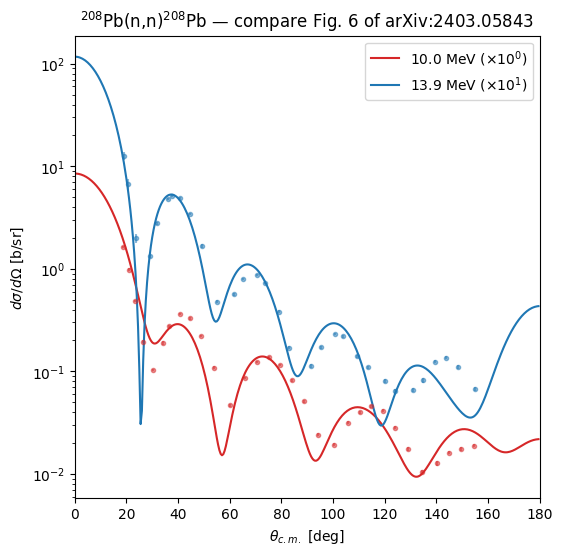

In [11]:
fig, ax = plt.subplots(figsize=(6, 6))
deg = angles * 180 / np.pi
colors = ("tab:red", "tab:blue")
groups_sorted = sorted(groups, key=lambda g: g[0].Einc)
for i, (Elab, group) in enumerate(zip(Elab_da, groups_sorted, strict=True)):
    offset = 10.0**i
    for m in group:
        # EXFOR dXS/dA comes back in b/sr
        ax.errorbar(
            m.x,
            offset * m.y,
            yerr=offset * m.statistical_err,
            ls="none",
            marker="o",
            markersize=3,
            color=colors[i],
            alpha=0.5,
        )
    ax.semilogy(
        deg,
        offset * dsdo[i] / 1000,
        color=colors[i],
        label=rf"{Elab:.1f} MeV ($\times 10^{{{i}}}$)",
    )
ax.set_xlabel(r"$\theta_{c.m.}$ [deg]")
ax.set_ylabel(r"$d\sigma/d\Omega$ [b/sr]")
ax.set_title(r"$^{208}$Pb(n,n)$^{208}$Pb — compare Fig. 6 of arXiv:2403.05843")
ax.legend()
ax.set_xlim([0, 180]);

## 4. Total cross section, 0.3–250 MeV (paper Fig. 5)

One energy-vectorized workspace per energy decade (so `lmax` can follow the
grazing angular momentum), each solving its whole grid in one call. EXFOR
$n + {}^{208}$Pb total cross sections overlaid.

In [12]:
exfor_tot_rxn = exfor_tools.reaction.Reaction(
    target=target, projectile=neutron, process="TOT"
)
entries_tot, _ = robust_query(exfor_tot_rxn, "XS", [0.3, 250])
E_tot_exp, xs_tot_exp = [], []
for entry in entries_tot.values():
    for m in entry.measurements:
        E_tot_exp.append(np.atleast_1d(m.x))  # MeV
        xs_tot_exp.append(np.atleast_1d(m.y))  # barns
E_tot_exp = np.concatenate(E_tot_exp)
xs_tot_exp = np.concatenate(xs_tot_exp)
print(f"{E_tot_exp.size} EXFOR total-xs points")

15793 EXFOR total-xs points


In [13]:
chunks = [
    (np.geomspace(0.3, 5.0, 20), 16),
    (np.geomspace(5.0, 50.0, 18), 32),
    (np.geomspace(50.0, 250.0, 14), None),  # lmax from suggest_lmax
]
E_model, sigt_model = [], []
for Elab_chunk, lmax in chunks:
    if lmax is None:
        lmax = jitr.xs.elastic.suggest_lmax(reaction, float(Elab_chunk[-1]), R_FM)
    kin = reaction.kinematics(Elab_chunk)
    ws = jitr.xs.elastic.IntegralWorkspace(
        reaction=reaction,
        kinematics=kin,
        channel_radius_fm=R_FM,
        nbasis=50,
        lmax=lmax,
    )
    V = mbra_interaction(ws, reaction, kin)
    sig_t, _ = ws.xs(V)
    E_model.append(Elab_chunk)
    sigt_model.append(np.asarray(sig_t))
E_model = np.concatenate(E_model)
sigt_model = np.concatenate(sigt_model)

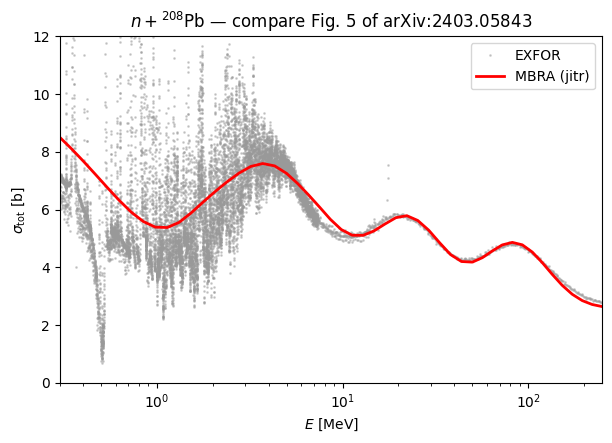

In [14]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.semilogx(
    E_tot_exp,
    xs_tot_exp,
    ".",
    color="0.6",
    markersize=2,
    alpha=0.4,
    label="EXFOR",
    rasterized=True,
)
ax.semilogx(E_model, sigt_model / 1000, "r-", lw=2, label="MBRA (jitr)")
ax.set_xlabel(r"$E$ [MeV]")
ax.set_ylabel(r"$\sigma_{\rm tot}$ [b]")
ax.set_title(r"$n + {}^{208}$Pb — compare Fig. 5 of arXiv:2403.05843")
ax.set_xlim([0.3, 250])
ax.set_ylim([0, 12])
ax.legend();

The model reproduces the Ramsauer oscillations of the averaged total cross
section over three decades of energy, and the diffraction pattern of the
differential cross sections — compare with Figs. 5 and 6 of the paper. Note
that below a few MeV the measured total cross section fluctuates with
compound-nucleus resonances; the optical model (and the paper's calibration)
describes the energy-averaged cross section there.